In [0]:
# ============================================================
# AG4P-7 | Correlation & Feature Analysis
# Platform : Databricks Community Edition
# Input    : /Volumes/weather/weather15/up15/agro_up_clean.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#c9ccd6',
    'text.color'       : '#c9ccd6',
    'xtick.color'      : '#8b8fa8',
    'ytick.color'      : '#8b8fa8',
    'grid.color'       : '#2a2d3a',
    'grid.alpha'       : 0.5,
})

ACCENT = ['#4e8ef7','#f76e6e','#56d98e','#f7c948',
          '#b48ef7','#f7914e','#4ec9f7','#f74e8e']
SAVE   = '/tmp/agro_eda/'

import os
os.makedirs(SAVE, exist_ok=True)

df = pd.read_csv(
    '/Volumes/weather/weather15/up15/agro_up_clean.csv',
    low_memory=False
)
df['date']  = pd.to_datetime(df['date'], errors='coerce')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

# All numeric columns for correlation
NUMERIC_COLS = [
    'temp_mean', 'temp_max', 'temp_min',
    'humidity_mean', 'dew_mean',
    'precip_total', 'precip_max', 'rain_occurred',
    'cloud_mean', 'cloud_low_mean',
    'cloud_mid_mean', 'cloud_high_mean',
    'wind_mean_10m', 'wind_max_10m',
    'wind_mean_100m', 'wind_max_100m',
    'wind_std_100m', 'wind_gusts_max',
    'pressure_mean', 'surface_pressure_mean'
]
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df.columns]

print("=" * 60)
print("AG4P-7 | STEP 1 - Setup Complete")
print("=" * 60)
print("  Rows         :", len(df))
print("  Numeric cols :", len(NUMERIC_COLS))
print("  Cols         :", NUMERIC_COLS)

AG4P-7 | STEP 1 - Setup Complete
  Rows         : 258200
  Numeric cols : 20
  Cols         : ['temp_mean', 'temp_max', 'temp_min', 'humidity_mean', 'dew_mean', 'precip_total', 'precip_max', 'rain_occurred', 'cloud_mean', 'cloud_low_mean', 'cloud_mid_mean', 'cloud_high_mean', 'wind_mean_10m', 'wind_max_10m', 'wind_mean_100m', 'wind_max_100m', 'wind_std_100m', 'wind_gusts_max', 'pressure_mean', 'surface_pressure_mean']


AG4P-7 | STEP 2 - Full Correlation Matrix


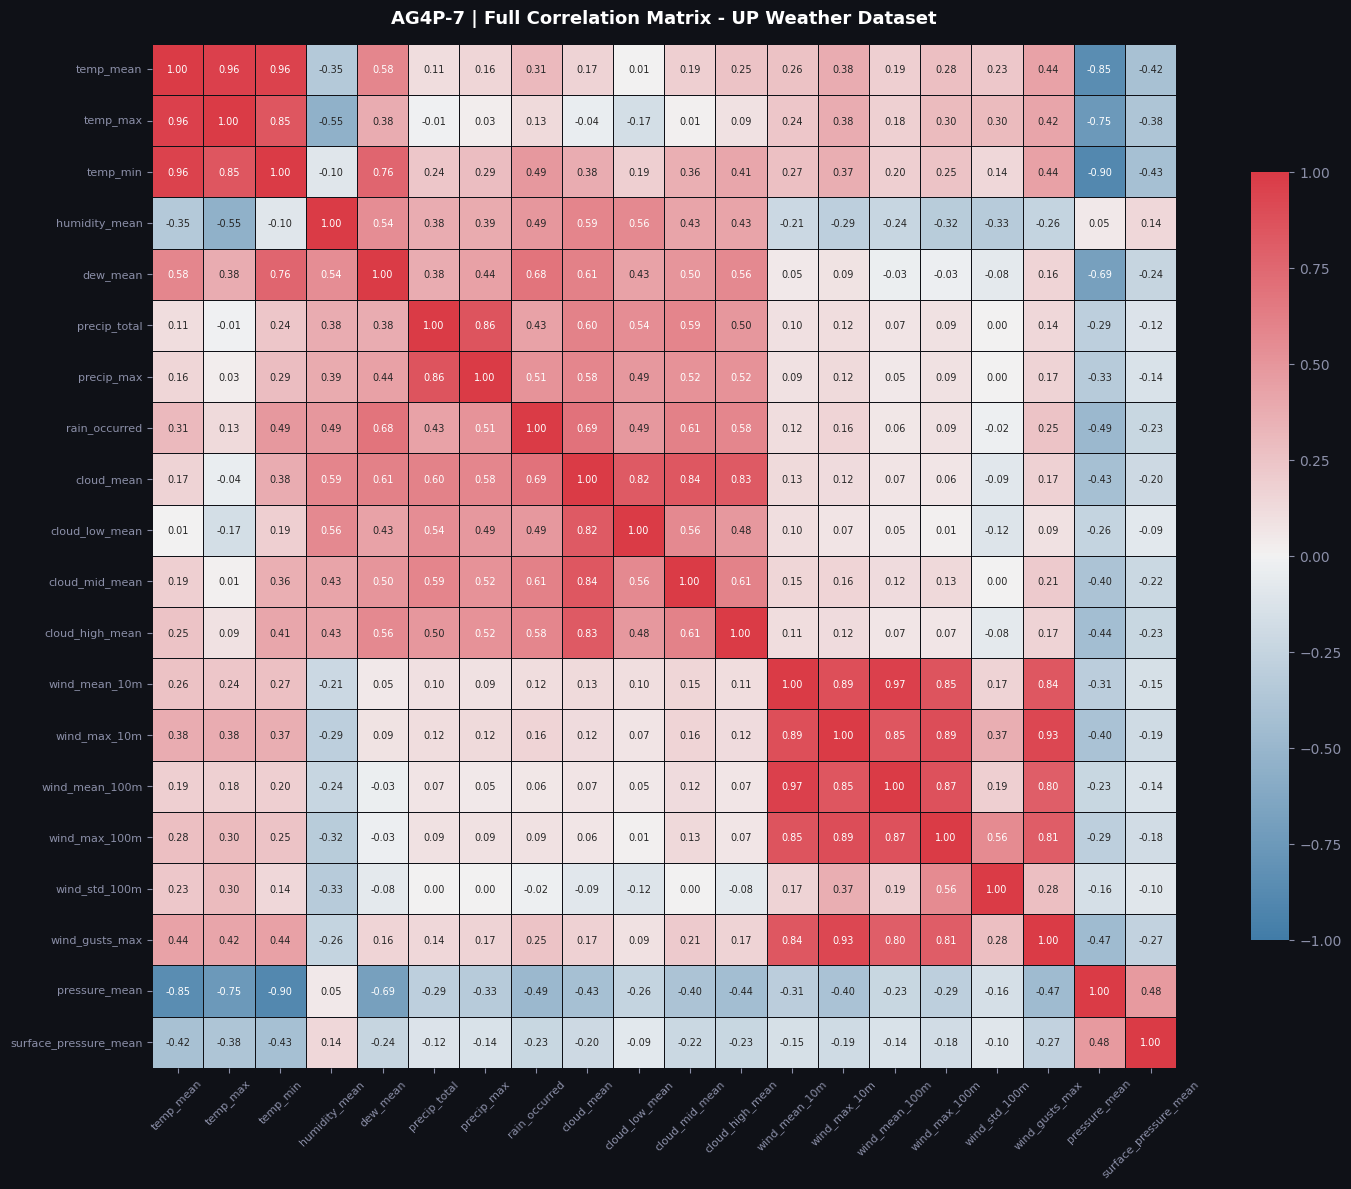

Saved: ag4p7_correlation_matrix.png


In [0]:
print("=" * 60)
print("AG4P-7 | STEP 2 - Full Correlation Matrix")
print("=" * 60)

corr = df[NUMERIC_COLS].corr().round(3)

fig, ax = plt.subplots(figsize=(16, 12))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    corr,
    ax          = ax,
    cmap        = cmap,
    vmin        = -1,
    vmax        = 1,
    annot       = True,
    fmt         = '.2f',
    annot_kws   = {'size': 7},
    linewidths  = 0.5,
    linecolor   = '#0f1117',
    square      = True,
    cbar_kws    = {'shrink': 0.75}
)

ax.set_title(
    'AG4P-7 | Full Correlation Matrix - UP Weather Dataset',
    fontsize=13, fontweight='bold', color='white', pad=15
)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(
    SAVE + 'ag4p7_correlation_matrix.png',
    dpi=150, bbox_inches='tight', facecolor='#0f1117'
)
plt.show()
print("Saved: ag4p7_correlation_matrix.png")

High Correlation Pairs

In [0]:
print("=" * 60)
print("AG4P-7 | STEP 3 - High Correlation Pairs")
print("=" * 60)

high_corr  = []
watch_corr = []

for i in range(len(NUMERIC_COLS)):
    for j in range(i + 1, len(NUMERIC_COLS)):
        r  = corr.iloc[i, j]
        c1 = NUMERIC_COLS[i]
        c2 = NUMERIC_COLS[j]

        if abs(r) > 0.90:
            high_corr.append((c1, c2, round(r, 3)))
        elif abs(r) > 0.80:
            watch_corr.append((c1, c2, round(r, 3)))

print("  CRITICAL (|r| > 0.90) — consider dropping one:")
print("  " + "-" * 55)
for c1, c2, r in sorted(
    high_corr, key=lambda x: abs(x[2]), reverse=True
):
    print(" ", c1.ljust(24), "<->", c2.ljust(24), r)

print()
print("  WATCH (|r| 0.80-0.90) — multicollinearity risk:")
print("  " + "-" * 55)
for c1, c2, r in sorted(
    watch_corr, key=lambda x: abs(x[2]), reverse=True
):
    print(" ", c1.ljust(24), "<->", c2.ljust(24), r)

AG4P-7 | STEP 3 - High Correlation Pairs
  CRITICAL (|r| > 0.90) — consider dropping one:
  -------------------------------------------------------
  wind_mean_10m            <-> wind_mean_100m           0.966
  temp_mean                <-> temp_max                 0.961
  temp_mean                <-> temp_min                 0.956
  wind_max_10m             <-> wind_gusts_max           0.925

  WATCH (|r| 0.80-0.90) — multicollinearity risk:
  -------------------------------------------------------
  temp_min                 <-> pressure_mean            -0.895
  wind_max_10m             <-> wind_max_100m            0.892
  wind_mean_10m            <-> wind_max_10m             0.888
  wind_mean_100m           <-> wind_max_100m            0.874
  precip_total             <-> precip_max               0.859
  temp_mean                <-> pressure_mean            -0.854
  wind_mean_10m            <-> wind_max_100m            0.854
  wind_max_10m             <-> wind_mean_100m           0.8

PS1 Feature Correlation with Target

AG4P-7 | STEP 4 - PS1 Feature Relevance
         Target: temp_mean (Season Onset)
  Feature correlation with temp_mean:
  --------------------------------------------------
  pressure_mean              -█████████████████████░░░░ -0.854
  dew_mean                   +██████████████░░░░░░░░░░░ 0.585
  wind_gusts_max             +██████████░░░░░░░░░░░░░░░ 0.437
  surface_pressure_mean      -██████████░░░░░░░░░░░░░░░ -0.419
  humidity_mean              -████████░░░░░░░░░░░░░░░░░ -0.347
  rain_occurred              +███████░░░░░░░░░░░░░░░░░░ 0.311
  wind_max_100m              +██████░░░░░░░░░░░░░░░░░░░ 0.279
  cloud_high_mean            +██████░░░░░░░░░░░░░░░░░░░ 0.252
  wind_std_100m              +█████░░░░░░░░░░░░░░░░░░░░ 0.234
  cloud_mid_mean             +████░░░░░░░░░░░░░░░░░░░░░ 0.191
  wind_mean_100m             +████░░░░░░░░░░░░░░░░░░░░░ 0.189
  cloud_mean                 +████░░░░░░░░░░░░░░░░░░░░░ 0.169
  precip_total               +██░░░░░░░░░░░░░░░░░░░░░░░ 0.11
  cloud_low_mean   

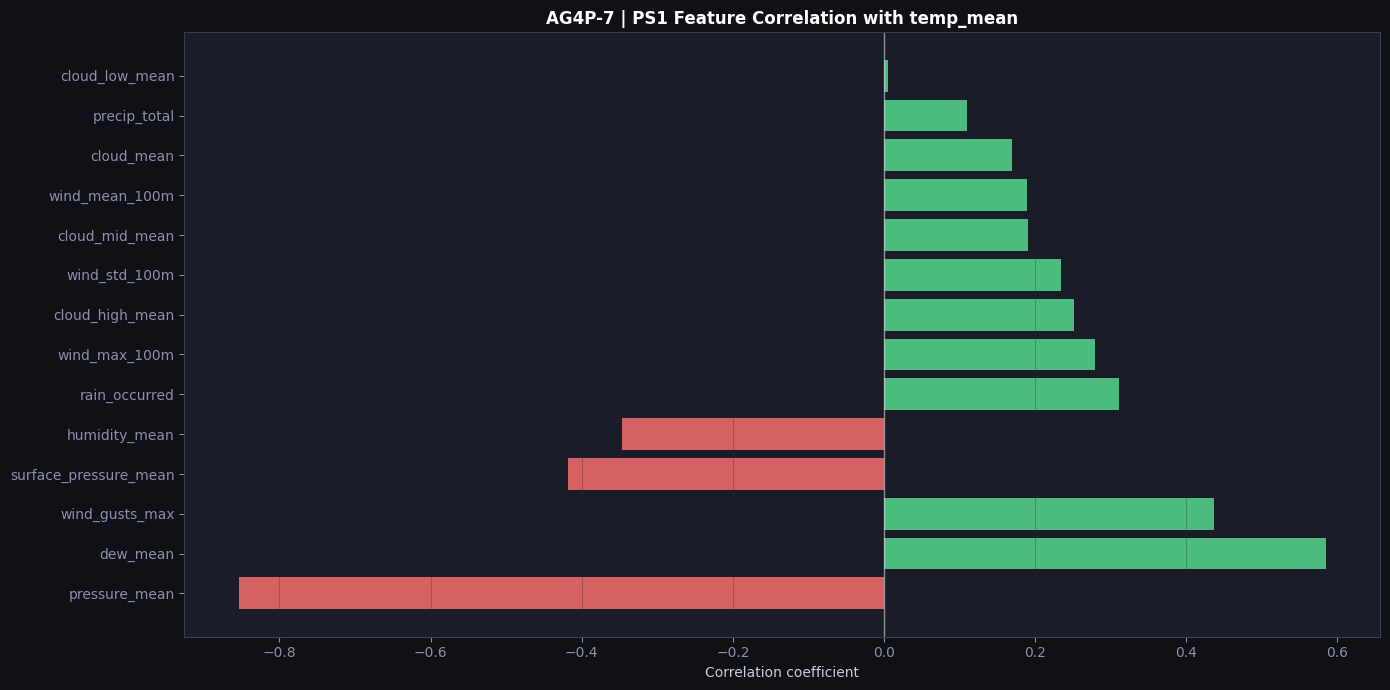

Saved: ag4p7_ps1_feature_corr.png


In [0]:
print("=" * 60)
print("AG4P-7 | STEP 4 - PS1 Feature Relevance")
print("         Target: temp_mean (Season Onset)")
print("=" * 60)

PS1_FEATURES = [
    'humidity_mean', 'dew_mean', 'pressure_mean',
    'surface_pressure_mean', 'cloud_mean',
    'cloud_low_mean', 'cloud_mid_mean', 'cloud_high_mean',
    'wind_mean_100m', 'wind_max_100m', 'wind_std_100m',
    'wind_gusts_max', 'precip_total', 'rain_occurred'
]
PS1_FEATURES = [c for c in PS1_FEATURES if c in df.columns]

ps1_corr = df[PS1_FEATURES + ['temp_mean']].corr()[
    'temp_mean'
].drop('temp_mean').sort_values(key=abs, ascending=False)

print("  Feature correlation with temp_mean:")
print("  " + "-" * 50)
for feat, val in ps1_corr.items():
    bar    = int(abs(val) * 25)
    filled = '█' * bar + '░' * (25 - bar)
    sign   = '+' if val >= 0 else '-'
    print(" ", feat.ljust(26), sign + filled, round(val, 3))

# Bar chart
fig, ax = plt.subplots(figsize=(14, 7))
colors  = ['#56d98e' if v > 0 else '#f76e6e'
           for v in ps1_corr.values]

ax.barh(
    ps1_corr.index,
    ps1_corr.values,
    color       = colors,
    alpha       = 0.85,
    edgecolor   = 'none'
)
ax.axvline(0, color='white', lw=1, alpha=0.5)
ax.set_title(
    'AG4P-7 | PS1 Feature Correlation with temp_mean',
    fontsize=12, fontweight='bold', color='white'
)
ax.set_xlabel('Correlation coefficient')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(
    SAVE + 'ag4p7_ps1_feature_corr.png',
    dpi=150, bbox_inches='tight', facecolor='#0f1117'
)
plt.show()
print("Saved: ag4p7_ps1_feature_corr.png")

PS2 Feature Independence Check

AG4P-7 | STEP 5 - PS2 Clustering Feature Independence
         Goal: low inter-correlation = better clusters


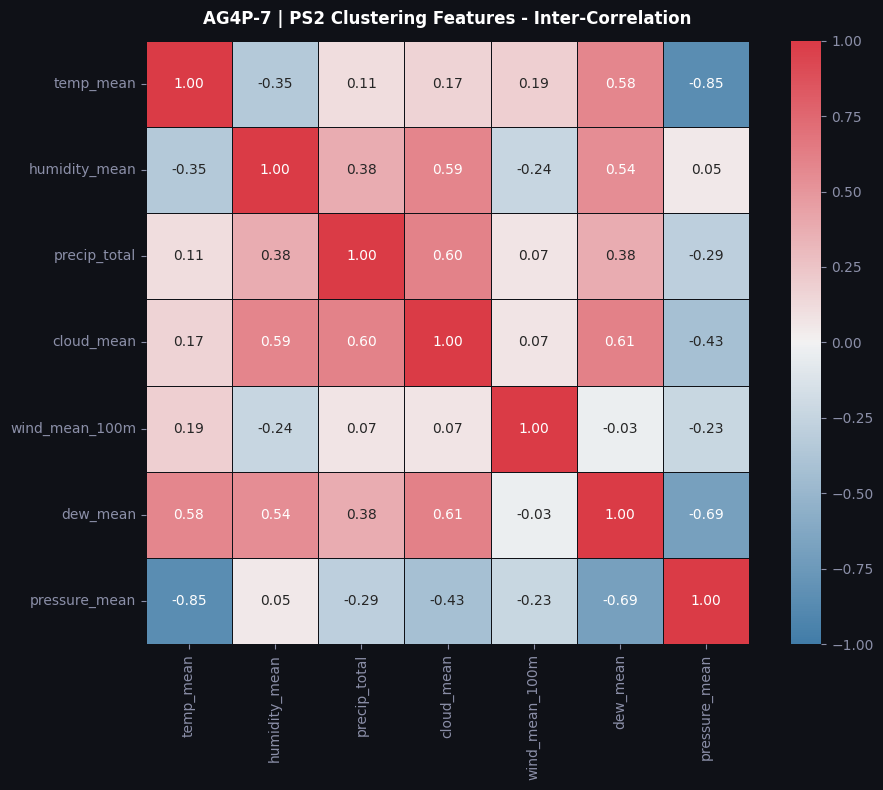

Saved: ag4p7_ps2_cluster_corr.png

  High correlation pairs within PS2 feature set:
  temp_mean <-> pressure_mean : -0.854 WATCH


In [0]:
print("=" * 60)
print("AG4P-7 | STEP 5 - PS2 Clustering Feature Independence")
print("         Goal: low inter-correlation = better clusters")
print("=" * 60)

# For clustering we want features that are NOT correlated
# Each feature should add unique information
PS2_FEATURES = [
    'temp_mean', 'humidity_mean', 'precip_total',
    'cloud_mean', 'wind_mean_100m', 'dew_mean',
    'pressure_mean'
]
PS2_FEATURES = [c for c in PS2_FEATURES if c in df.columns]

ps2_corr = df[PS2_FEATURES].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))
cmap    = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(
    ps2_corr,
    ax        = ax,
    cmap      = cmap,
    vmin      = -1,
    vmax      = 1,
    annot     = True,
    fmt       = '.2f',
    annot_kws = {'size': 10},
    linewidths= 0.5,
    linecolor = '#0f1117',
    square    = True
)
ax.set_title(
    'AG4P-7 | PS2 Clustering Features - Inter-Correlation',
    fontsize=12, fontweight='bold', color='white', pad=12
)
plt.tight_layout()
plt.savefig(
    SAVE + 'ag4p7_ps2_cluster_corr.png',
    dpi=150, bbox_inches='tight', facecolor='#0f1117'
)
plt.show()
print("Saved: ag4p7_ps2_cluster_corr.png")

# Flag any high pairs within PS2 feature set
print()
print("  High correlation pairs within PS2 feature set:")
found = False
for i in range(len(PS2_FEATURES)):
    for j in range(i + 1, len(PS2_FEATURES)):
        r  = ps2_corr.iloc[i, j]
        c1 = PS2_FEATURES[i]
        c2 = PS2_FEATURES[j]
        if abs(r) > 0.80:
            print(" ", c1, "<->", c2, ":", r, "WATCH")
            found = True
if not found:
    print("  None — all PS2 features carry independent signal")

PS3 Feature Correlation

In [0]:
print("=" * 60)
print("AG4P-7 | STEP 6 - PS3 Feature Relevance")
print("         Target: wind_mean_100m (Energy Potential)")
print("=" * 60)

PS3_FEATURES = [
    'cloud_mean', 'cloud_low_mean', 'cloud_mid_mean',
    'cloud_high_mean', 'pressure_mean',
    'surface_pressure_mean', 'humidity_mean',
    'temp_mean', 'precip_total', 'rain_occurred'
]
PS3_FEATURES = [c for c in PS3_FEATURES if c in df.columns]

ps3_corr = df[PS3_FEATURES + ['wind_mean_100m']].corr()[
    'wind_mean_100m'
].drop('wind_mean_100m').sort_values(key=abs, ascending=False)

print("  Feature correlation with wind_mean_100m:")
print("  " + "-" * 50)
for feat, val in ps3_corr.items():
    bar    = int(abs(val) * 25)
    filled = '█' * bar + '░' * (25 - bar)
    sign   = '+' if val >= 0 else '-'
    print(" ", feat.ljust(28), sign + filled, round(val, 3))

# Wind vs cloud correlation — key PS3 insight
if 'cloud_mean' in df.columns:
    wc_corr = df['wind_mean_100m'].corr(df['cloud_mean'])
    print()
    print("  wind_mean_100m <-> cloud_mean :", round(wc_corr, 3))
    if wc_corr > 0:
        print("  Positive — windier days tend to have more cloud")
        print("  This means wind and solar are competing signals")
        print("  for PS3 — a city strong in both is rare")
    else:
        print("  Negative — windier days tend to be clearer")
        print("  Wind and solar reinforce each other for PS3")

AG4P-7 | STEP 6 - PS3 Feature Relevance
         Target: wind_mean_100m (Energy Potential)
  Feature correlation with wind_mean_100m:
  --------------------------------------------------
  humidity_mean                -█████░░░░░░░░░░░░░░░░░░░░ -0.24
  pressure_mean                -█████░░░░░░░░░░░░░░░░░░░░ -0.233
  temp_mean                    +████░░░░░░░░░░░░░░░░░░░░░ 0.189
  surface_pressure_mean        -███░░░░░░░░░░░░░░░░░░░░░░ -0.138
  cloud_mid_mean               +██░░░░░░░░░░░░░░░░░░░░░░░ 0.118
  cloud_mean                   +█░░░░░░░░░░░░░░░░░░░░░░░░ 0.075
  precip_total                 +█░░░░░░░░░░░░░░░░░░░░░░░░ 0.074
  cloud_high_mean              +█░░░░░░░░░░░░░░░░░░░░░░░░ 0.067
  rain_occurred                +█░░░░░░░░░░░░░░░░░░░░░░░░ 0.06
  cloud_low_mean               +█░░░░░░░░░░░░░░░░░░░░░░░░ 0.052

  wind_mean_100m <-> cloud_mean : 0.075
  Positive — windier days tend to have more cloud
  This means wind and solar are competing signals
  for PS3 — a city strong in bo

 VIF Table for PS1

In [0]:
print("=" * 60)
print("AG4P-7 | STEP 7 - VIF Table for PS1 Feature Set")
print("         VIF > 10 = severe multicollinearity")
print("=" * 60)

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif_features = [
        'humidity_mean', 'dew_mean', 'pressure_mean',
        'cloud_mean', 'wind_mean_100m',
        'wind_gusts_max', 'precip_total'
    ]
    vif_features = [c for c in vif_features if c in df.columns]
    vif_data     = df[vif_features].dropna()

    vif_df = pd.DataFrame({
        'Feature' : vif_features,
        'VIF'     : [
            round(variance_inflation_factor(
                vif_data.values, i
            ), 2)
            for i in range(len(vif_features))
        ]
    }).sort_values('VIF', ascending=False)

    vif_df['Flag'] = vif_df['VIF'].apply(
        lambda v:
        'DROP -- severe multicollinearity' if v > 10 else
        'WATCH'                            if v > 5  else
        'OK'
    )

    print("  Feature              VIF     Flag")
    print("  " + "-" * 48)
    for _, row in vif_df.iterrows():
        print(" ", row['Feature'].ljust(22),
              str(row['VIF']).rjust(6), " ", row['Flag'])

except ImportError:
    print("  statsmodels not available")
    print("  Run: pip install statsmodels")
    print("  Skipping VIF — using correlation as proxy instead")
    print()
    print("  High correlation pairs in PS1 set (proxy for VIF):")
    ps1_self = df[vif_features if 'vif_features' in dir()
                  else PS1_FEATURES].corr()
    for i in range(len(ps1_self)):
        for j in range(i + 1, len(ps1_self)):
            r = ps1_self.iloc[i, j]
            if abs(r) > 0.85:
                print(" ", ps1_self.index[i],
                      "<->", ps1_self.columns[j],
                      ":", round(r, 3))

AG4P-7 | STEP 7 - VIF Table for PS1 Feature Set
         VIF > 10 = severe multicollinearity
  statsmodels not available
  Run: pip install statsmodels
  Skipping VIF — using correlation as proxy instead

  High correlation pairs in PS1 set (proxy for VIF):
  wind_mean_100m <-> wind_max_100m : 0.874
